<a href="https://colab.research.google.com/github/KeylaAH/KeylaAH/blob/main/Copy_of_Regression_Model_KAH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── Core Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: Models ───────────────────────────────────
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    HuberRegressor, RANSACRegressor,
    LogisticRegression, PoissonRegressor
)

# ── Scikit-learn: Preprocessing & Selection ────────────────
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV,
    learning_curve, KFold, validation_curve
)

# ── Scikit-learn: Metrics ──────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Scikit-learn: Imputation ───────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# ── Statsmodels ────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Global Settings ────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)
pd.set_option('display.precision', 4)
np.set_printoptions(precision=4, suppress=True)

# Utility: consistent plot formatting
def format_plot(ax, title, xlabel, ylabel, legend=True):
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    if legend:
        ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


In [ ]:
# Load Training data
train_data = pd.read_csv("regression_train.csv")


In [ ]:
#Check the data for missing nan values in order to choose features:
print(train_data.head(2))
print("")
print(f"missing values:")
print(train_data.isna().sum())      # check missing values
#print("")
#print(f"NaN values:")
#print(np.isnan(train_data).sum())   # count NaNs
print("")
print(f"inf values:")
print(np.isinf(train_data).sum())   # count infs
print(train_data.shape)


   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0     3.7454    12.5826    17.1892     0.7752    -0.5984    -0.5323   
1     9.5071     5.2459    18.9539     0.5530    -0.9666    -4.9290   

   feature_7  feature_8  feature_9  feature_10    target  
0     3.4701    13.9436     5.7820           1  321.2755  
1     9.7620     5.6681     3.0597           0  159.0228  

missing values:
feature_1      0
feature_2      0
feature_3     43
feature_4      0
feature_5     49
feature_6      0
feature_7     54
feature_8      0
feature_9      0
feature_10     0
target         0
dtype: int64

inf values:
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
target        0
dtype: int64
(1000, 11)


In [ ]:
#Checking for outliers in the data

for col in train_data.columns:

    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_data[(train_data[col] < lower_bound) | (train_data[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")



feature_1: 0 outliers
feature_2: 0 outliers
feature_3: 12 outliers
feature_4: 6 outliers
feature_5: 10 outliers
feature_6: 0 outliers
feature_7: 0 outliers
feature_8: 0 outliers
feature_9: 3 outliers
feature_10: 0 outliers
target: 1 outliers


In [ ]:
#check for strange values, looking for outliers

train_data.describe()


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target
count,1000.0000,1000.0000,957.0000,1000.0000,951.0000,1000.0000,946.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,4.9026,10.0095,20.0440,-0.0168,-0.0171,-0.1613,4.8904,10.0290,4.4575,1.0060,284.5842
std,2.9214,2.8801,4.8525,1.0221,0.9848,2.8425,2.9738,2.9375,1.5808,0.8041,105.5854
min,0.0463,5.0322,4.9024,-2.9294,-3.1767,-4.9976,-0.6766,4.2434,-0.6339,0.0000,92.9591
25%,2.3597,7.4312,16.7926,-0.7371,-0.6670,-2.5868,2.2665,7.5532,3.3464,0.0000,200.4042
50%,4.9681,10.0780,20.0026,0.0039,0.0013,-0.1494,4.8995,10.1285,4.4852,1.0000,265.5789
75%,7.4432,12.4346,23.1920,0.6669,0.6566,2.1419,7.3723,12.4878,5.5584,2.0000,356.2488
max,9.9972,14.9941,35.6887,3.2431,3.1129,4.9890,10.7838,16.1222,8.9508,2.0000,590.7682


In [ ]:
#Cleaning the data for missing values from so it can be used
print(train_data.shape)
# Remove rows with NaN values
train_clean = train_data[~np.isnan(train_data).any(axis=1)]
print(train_clean.shape)


(1000, 11)
(863, 11)


In [ ]:
#checking which features have more correlations with the target
#train_data.corr()["target"]
#print("\n Clean data\n")
#train_clean.corr()["target"]

In [ ]:
#checking which features have more correlations with the target
#train_data.corr()["target"]
#print("\n Clean data\n")
train_clean.corr()["target"]

,target
feature_1,0.6399
feature_2,0.6694
feature_3,0.0765
feature_4,-0.0155
feature_5,0.0267
feature_6,0.0148
feature_7,0.6273
feature_8,0.6624
feature_9,0.7186
feature_10,0.0621


In [ ]:
#Check the data for missing nan after cleaning
#the data

print(f"missing values:")
print(train_clean.isna().sum())      # check missing values
print("")
print(f"NaN values:")
print(np.isnan(train_clean).sum())   # count NaNs



missing values:
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
target        0
dtype: int64

NaN values:
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
target        0
dtype: int64


In [ ]:

#choosing 3 out of 10 columns to use in our model
#I choose 1, 2 and 4 becuase they dont have missing values
X_multi = train_clean[["feature_1", "feature_2", 'feature_6']].values
y_multi = train_clean["target"].values


print("X_multi:")
print(X_multi[:3])
print("y_multi:")
print(y_multi[:3])
print("--"*20)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_multi)

# Add column of 1s for intercept
X_design = np.column_stack([np.ones(len(X_poly)), X_poly])
print("X_design:")
print(X_design[:3])

X_multi:
[[ 3.7454 12.5826 -0.5323]
 [ 9.5071  5.2459 -4.929 ]
 [ 7.3199  5.2212  3.194 ]]
y_multi:
[321.2755 159.0228 174.8667]
----------------------------------------
X_design:
[[  1.       3.7454  12.5826  -0.5323  14.028   47.127   -1.9936 158.3226
   -6.6975   0.2833]
 [  1.       9.5071   5.2459  -4.929   90.3858  49.8732 -46.861   27.5191
  -25.8571  24.2954]
 [  1.       7.3199   5.2212   3.194   53.5815  38.2191  23.3798  27.2613
   16.6765  10.2015]]


In [ ]:
# From Scratch: Normal Equations
# Calculate the w's
# w = (X^T X)^(-1) X^T y
XtX = X_design.T @ X_design
Xty = X_design.T @ y_multi
w_scratch = np.linalg.inv(XtX) @ Xty

print("==Plynomial Regression(from scratch)==")
print(w_scratch)

print("=== Multiple Regression (from scratch) ===")
print(f"Intercept (w0):          {w_scratch[0]:.4f}")
print(f"train coeff (w1):  {w_scratch[1]:.4f}")
print(f"train coeff (w2):  {w_scratch[2]:.4f}")
print(f"train coeff (w3):  {w_scratch[3]:.4f}")
#print(f"train coeff (w4):  {w_scratch[4]:.4f}")

#using sklearn and verifying they match
#train model with Huber Regression instead of Linear Regression
#to improve the outliers
#model_multi = LinearRegression()
#model_multi.fit(X_multi, y_multi)

#model_multi = HuberRegressor(epsilon = 1.35)
#model_multi.fit(X_multi, y_multi)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

model_multi = Pipeline([
    ("scale", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", HuberRegressor(epsilon = 1.35))
])

model_multi.fit(X_multi, y_multi)


#assert np.allclose(w_scratch[0], model_multi.intercept_, rtol=1e-4)
#assert np.allclose(w_scratch[1:], model_multi.coef_, rtol=1e-4)
#print("\nScratch and sklearn results match")

==Plynomial Regression(from scratch)==
[89.6756  3.2273  4.9339 -0.9481 -2.0774  4.0406  0.0185 -0.006   0.0807
  0.0148]
=== Multiple Regression (from scratch) ===
Intercept (w0):          89.6756
train coeff (w1):  3.2273
train coeff (w2):  4.9339
train coeff (w3):  -0.9481


Pipeline(steps=[('scale', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', HuberRegressor())])

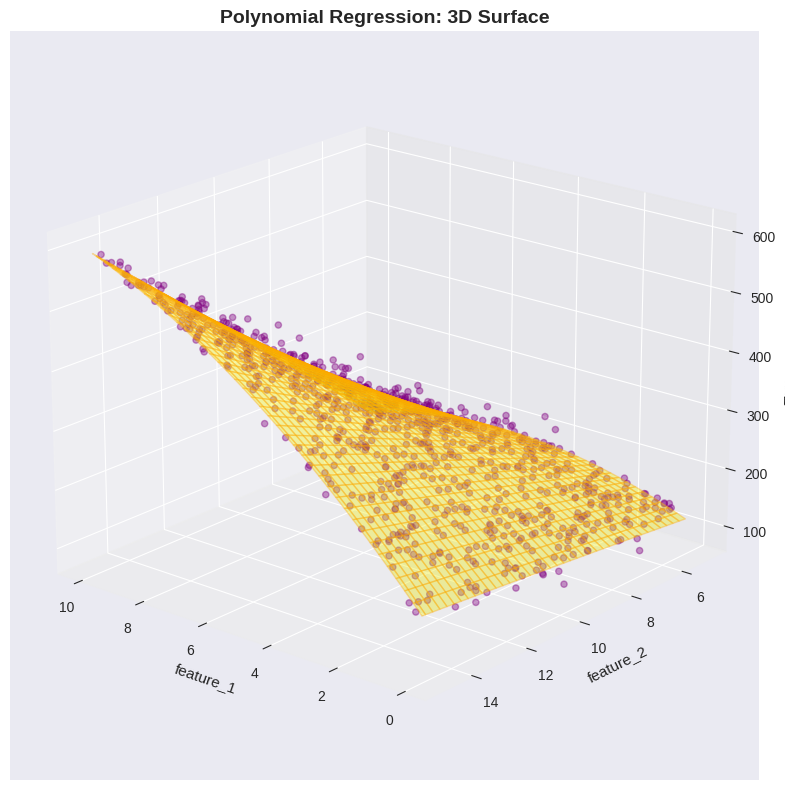

In [ ]:
# ── 3D Surface Plot ─────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter points
ax.scatter(X_multi[:, 0], X_multi[:, 1], y_multi,
           alpha=0.4, s=20, c='purple', label='Data')

# Regression surface
xx, yy = np.meshgrid(
    np.linspace(X_multi[:, 0].min(), X_multi[:, 0].max(), 80),
    np.linspace(X_multi[:, 1].min(), X_multi[:, 1].max(), 80),
)

#Since we are using one more feature we will graph the mean of it.
f6_mean = X_multi[:, 2].mean()

# Create a grid of points for prediction
X_plot_surface = np.c_[xx.ravel(),
                       yy.ravel(),
                       np.full_like(xx.ravel(),
                      f6_mean)] # plus the mean of 3rd feature

# Use the pipeline's predict method for correct transformation and prediction
zz = model_multi.predict(X_plot_surface)
zz = zz.reshape(xx.shape) # Reshape back to the original grid shape

ax.plot_surface(xx, yy, zz, alpha=0.35, color='yellow', edgecolor = 'orange')

# Correcting labels to match the features plotted
ax.set_xlabel('feature_1', fontsize=11)
ax.set_ylabel('feature_2', fontsize=11)
ax.set_zlabel('Target', fontsize=11)
ax.set_title('Polynomial Regression: 3D Surface', fontsize=14, fontweight='bold')
ax.view_init(elev=20, azim=130)
plt.tight_layout()
plt.show()


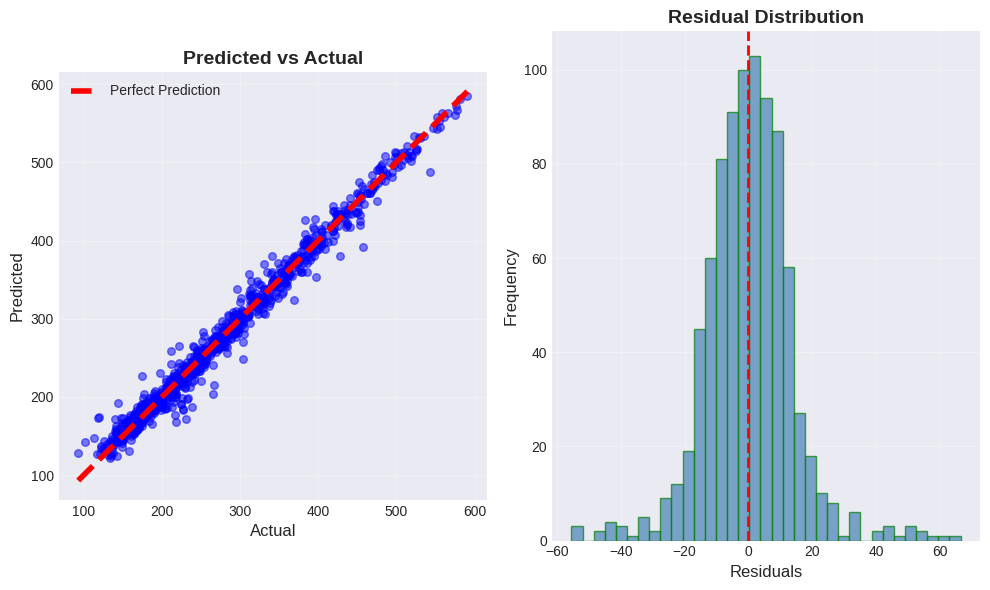

Mean Residual: 0.0379 ->should be around 0
Std of residuals: 13.8962


In [ ]:
from matplotlib import axes
# Predictions vs actuals
y_pred_multi = model_multi.predict(X_multi)
residuals = y_multi - y_pred_multi

fig, axes = plt.subplots(1,2, figsize=(10, 6))

#Left: Predicted vs Actual
axes[0].scatter(y_multi, y_pred_multi, alpha=0.5, s=30, color = 'blue')
lims = [min(y_multi.min(), y_pred_multi.min()),
        max(y_multi.max(), y_pred_multi.max())]
axes[0].plot(lims, lims, 'r--', linewidth = 4, label = 'Perfect Prediction')
axes[0].set_aspect('equal', adjustable='box')


format_plot(axes[0], 'Predicted vs Actual', 'Actual', 'Predicted')

#Right: Residual distribution
axes[1].hist(residuals, bins = 35,
             edgecolor = 'green' ,
             alpha =  0.7,
             color = 'steelblue')

axes[1].axvline(0, color = 'red', linewidth = 2, linestyle = '--')
format_plot(axes[1], 'Residual Distribution', 'Residuals', 'Frequency', legend = False)

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f} ->should be around 0")
print( f"Std of residuals: {residuals.std():.4f}")


In [ ]:
#Train/Test Split (80/20)

X = train_clean[['feature_1', 'feature_2', 'feature_6']].values
y = train_clean['target'].values

print("Features: X")
print(X[:3])
print("\nTarget: y")
print(y[:3])
print("")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state =42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

#Fit on traning data only
#This was traning a linear regression with hubber
#model_eval = HuberRegressor(epsilon = 1.35).fit(X_train, y_train)
# Now we are tranning a polynommial regression

model_eval = Pipeline([
    ("scale", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", HuberRegressor(epsilon = 1.35))
])

model_eval.fit(X_train, y_train)

y_train_pred = model_eval.predict(X_train)
y_test_pred = model_eval.predict(X_test)


comparission_test = pd.DataFrame({'Actual y': y_test, 'Predicted y': y_test_pred, 'Difference': (y_test - y_test_pred)})
print("Actual vs Predicted  Difference:")


#comparison_test["Difference"] = comparission_test["Actual y"] - comparission_test["Predicted y"]

print(comparission_test.head(20))






Features: X
[[ 3.7454 12.5826 -0.5323]
 [ 9.5071  5.2459 -4.929 ]
 [ 7.3199  5.2212  3.194 ]]

Target: y
[321.2755 159.0228 174.8667]

Training set size: 690
Test set size: 173
Actual vs Predicted  Difference:
    Actual y  Predicted y  Difference
0   170.2232     182.2313    -12.0081
1   336.4984     325.7537     10.7447
2   271.2096     289.7548    -18.5452
3   425.5242     430.9241     -5.3999
4   404.8849     411.1854     -6.3005
5   415.7888     418.5666     -2.7778
6   167.9179     165.4213      2.4965
7   244.7283     253.6916     -8.9633
8   348.6589     340.2215      8.4373
9   423.0581     433.5656    -10.5075
10  179.8234     173.6935      6.1299
11  447.9355     436.9654     10.9701
12  148.1990     148.8816     -0.6826
13  519.3375     506.8231     12.5144
14  372.5815     369.8055      2.7760
15  215.6712     230.4941    -14.8229
16  518.9118     507.6568     11.2550
17  229.8636     218.6517     11.2119
18   92.9591     127.4375    -34.4784
19  214.5789     208.0030     

In [ ]:
# ── Metrics from Scratch ────────────────────────────────────
def rmse_scratch(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae_scratch(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_scratch(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

def adj_r2_scratch(y_true, y_pred, n_features):
    r2 = r2_scratch(y_true, y_pred)
    n = len(y_true)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

# ── Compute on train and test ──────────────────────────────
metrics = {}

n_poly_features = model_eval.named_steps['poly'].n_output_features_

for name, yt, yp in [('Train', y_train, y_train_pred),
                       ('Test', y_test, y_test_pred)]:
    metrics[name] = {
        'RMSE': rmse_scratch(yt, yp),
        'MAE':  mae_scratch(yt, yp),
        'R²':   r2_scratch(yt, yp),
        'Adj R²': adj_r2_scratch(yt, yp, X_train.shape[1])
    }

metrics_df = pd.DataFrame(metrics).round(4)
print("=== Regression Metrics ===")
print(metrics_df)

# Verify with sklearn
rmse_sk = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_sk = r2_score(y_test, y_test_pred)
assert np.allclose(metrics['Test']['RMSE'], rmse_sk, rtol=0.01)
assert np.allclose(metrics['Test']['R²'], r2_sk, rtol=0.01)
print("\n✅ Scratch metrics match sklearn!")

print("\n=== Sklearn Metrics ===")
print("RMSE:", rmse_sk)
print("R²:", r2_sk)


=== Regression Metrics ===
          Train     Test
RMSE    14.2938  12.2940
MAE     10.0833   9.7891
R²       0.9812   0.9880
Adj R²   0.9812   0.9878

✅ Scratch metrics match sklearn!

=== Sklearn Metrics ===
RMSE: 12.29403935543082
R²: 0.9879691363793786


In [ ]:
#Predict of new features for our test data

#Load test data
test_data = pd.read_csv("regression_test.csv")
 #check for missing values in the new data
print(test_data.isna().sum())
print(test_data.shape)
# store the same feature in an array
X_new = test_data[['feature_1', 'feature_2', 'feature_6']].values
print(X_new[:3])

#Predict using train model
predictions = model_eval.predict(X_new)
print(predictions[:3])

pred_data = pd.DataFrame({"Predicted Target": predictions})

pred_data.to_csv("test_predictions.csv", index=False)

print("Predictions saved to test_predictions.csv")


feature_1      0
feature_2      0
feature_3     17
feature_4      0
feature_5     11
feature_6      0
feature_7      6
feature_8      0
feature_9      0
feature_10     0
dtype: int64
(200, 10)
[[ 1.8513 14.768   1.0301]
 [ 5.419   6.1072 -4.4287]
 [ 8.7295  9.2255  3.9377]]
[269.7618 209.5521 330.4046]
Predictions saved to test_predictions.csv
